<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB11b · Python que vas a ver

**Parte 1 · Primeros pasos con Python — Lección intermedia (entre el NB11 y el NB12)**

> Con la Parte 1 has aprendido lo esencial de Python: `print`, variables, bucles, `if`, listas y funciones, y con eso has hecho aprender a un palo de escoba. En la Parte 2 llegan las matemáticas (vectores, matrices, pendientes) y las herramientas para dibujarlas y calcularlas. Y con ellas aparecerá código con **formas nuevas** que todavía no te he presentado: `figsize=(5, 5)`, `datos.shape`, `[[0.6, 0.1], [0.2, 0.3]]`, `if paso in [1, 2, 5]`, `from math import sqrt`...

Esta lección presenta esas formas **antes** de que las necesites, una a una y con calma, para que en la Parte 2 puedas concentrarte en las matemáticas. Son seis ideas pequeñas:

1. **Argumentos con nombre**: `round(3.14159, ndigits=2)`.
2. **Tuplas**: `(5, 5)`, listas que no se pueden cambiar.
3. **Listas de listas**: `[[1, 2], [3, 4]]`.
4. El operador **`in`**: "¿está esto dentro de aquello?".
5. **Métodos y atributos**: `lista.append(x)` frente a `math.pi`.
6. Las formas de **importar**: `import ... as ...` y `from ... import ...`.

Y en la práctica final las encontrarás todas juntas en un **script de MuJoCo de verdad**, que leerás línea a línea.


## 1 · Argumentos con nombre

### Lo que ya sabes

En el NB10 aprendiste que una función recibe **argumentos**, que se emparejan con sus **parámetros** por **orden**: el primero con el primero, el segundo con el segundo. Por ejemplo, `round` (NB06) recibe el número y cuántos decimales quieres:


In [1]:
print(round(3.14159, 2))

3.14


### Llamar a los argumentos por su nombre

Los parámetros de una función tienen **nombre**, y Python permite usarlo al llamarla, escribiendo `nombre=valor`. El segundo parámetro de `round` se llama `ndigits` ("número de cifras"):


In [2]:
print(round(3.14159, ndigits=2))

3.14


Hace exactamente lo mismo, pero ahora se **lee** qué significa ese 2. A esto se le llama **argumento con nombre** (o *keyword argument*). Las ventajas:

- **Se lee mejor**: `round(x, ndigits=2)` dice qué es el 2; `round(x, 2)` hay que saberlo.
- **El orden da igual**: con nombre, cada valor va a su parámetro aunque lo escribas en otro orden.
- **Puedes saltarte parámetros**: muchas funciones tienen parámetros **opcionales** (con un valor que se usa si no dices nada) y, con nombres, eliges solo el que te interesa.

Un ejemplo que ya conoces: `print`. Tiene un parámetro opcional, `sep` ("separador"), que dice qué poner **entre** las cosas que imprime (por defecto, un espacio), y otro, `end`, que dice qué poner **al final** (por defecto, un salto de línea):


In [3]:
print("cadera", "rodilla", "tobillo")
print("cadera", "rodilla", "tobillo", sep=" → ")
print("sin salto de línea...", end=" ")
print("...y sigo en la misma línea")

cadera rodilla tobillo
cadera → rodilla → tobillo
sin salto de línea... ...y sigo en la misma línea


La regla de escritura: en una llamada, **primero** los argumentos sin nombre (por orden) y **después** los que llevan nombre. `print(sep=" → ", "cadera")` da error.

### Valores por defecto en tus funciones

¿Cómo hace una función para tener parámetros opcionales? Escribiendo un **valor por defecto** con `=` en el `def`:


In [4]:
def recompensa(velocidad, esfuerzo, peso_vida=5.0):
    return peso_vida + 1.25 * velocidad - 0.1 * esfuerzo

print(recompensa(1.0, 0.2))                     # usa peso_vida = 5.0
print(recompensa(1.0, 0.2, peso_vida=0.0))      # sin el premio por estar vivo (la trampa del NB04)

6.23
1.23


Si no le das `peso_vida`, vale 5. Si se lo das, usa el tuyo. En la Parte 2 verás llamadas como `plt.figure(figsize=(5, 5))` o `uniform(-1, 1, size=10)`: son exactamente esto, funciones con parámetros opcionales que se eligen por su nombre. (Hay mucho más que contar sobre parámetros; lo verás a fondo en el NB23.)


## 2 · Tuplas

### Una lista que no se puede cambiar

Una **tupla** es una colección de valores, como una lista, pero escrita entre **paréntesis** en vez de corchetes, y con una diferencia importante: **no se puede cambiar** después de crearla (no se le añaden, quitan ni cambian elementos).


In [5]:
tamano = (5, 3)                 # una tupla: 5 de ancho, 3 de alto
print(tamano)
print(tamano[0], tamano[1])     # se lee como una lista: con índices desde 0
print(len(tamano))

(5, 3)
5 3
2


In [6]:
tamano[0] = 10

TypeError: 'tuple' object does not support item assignment

`TypeError: 'tuple' object does not support item assignment`: "las tuplas no permiten asignar elementos". Ese es su sentido: se usan para agrupar cosas que **van juntas y no deben cambiar**, como las dos medidas de un dibujo `(ancho, alto)`, las coordenadas de un punto `(x, y)` o el tamaño de una tabla `(filas, columnas)`.

### Ya las has usado sin saberlo

En el NB10, una función devolvía **dos** valores con `return a, b`, y los recogías con `x, y = funcion()`. Por dentro, `return a, b` devuelve una **tupla**: los paréntesis son opcionales cuando no hay confusión. Y "recoger" cada valor en su variable se llama **desempaquetar**:


In [7]:
punto = (0.3, 0.8)
x, y = punto                    # desempaquetar: x recibe el primero, y el segundo
print("x =", x, "| y =", y)

x = 0.3 | y = 0.8


### Tuplas en un bucle

Una forma muy común (la verás en la Parte 2): una **lista de tuplas** recorrida con un `for` que desempaqueta cada tupla en dos variables a la vez:


In [8]:
pruebas = [("lenta", 0.01), ("buena", 0.1), ("rápida", 0.5)]
for nombre, tasa in pruebas:
    print(nombre, "→", tasa)

lenta → 0.01
buena → 0.1
rápida → 0.5


En cada vuelta, el `for` coge una tupla, por ejemplo `("lenta", 0.01)`, y la desempaqueta: `nombre` recibe `"lenta"` y `tasa` recibe `0.01`.

### La tupla de un solo elemento

Un detalle raro que verás algún día: `(5)` **no** es una tupla, es solo el número 5 entre paréntesis (como en las cuentas, NB04b). Para una tupla de un elemento hay que poner una **coma**: `(5,)`. Lo que hace la tupla es la coma, más que los paréntesis.


## 3 · Listas de listas

### Una lista puede contener listas

Los elementos de una lista pueden ser **cualquier cosa**: números, textos... y también **otras listas**. Una lista de listas sirve para guardar datos en forma de **tabla** (filas y columnas). Por ejemplo, tres pasos de un robot, cada uno con su avance en x y en y:


In [9]:
pasos = [[0.6, 0.1],
         [0.4, -0.2],
         [0.5, 0.0]]
print(len(pasos), "pasos")
print("el segundo paso:", pasos[1])
print("su avance en y: ", pasos[1][1])

3 pasos
el segundo paso: [0.4, -0.2]
su avance en y:  -0.2


Para leer un elemento hacen falta **dos** índices, uno detrás de otro:

- `pasos[1]` es la **fila** 1 (la segunda): la lista `[0.4, -0.2]`.
- `pasos[1][1]` es el elemento 1 **de esa fila**: `-0.2`.

Se lee de izquierda a derecha: "de `pasos`, coge la fila 1; de esa fila, coge el elemento 1". (Python escribe la lista de una línea; el código de arriba la parte en tres líneas solo para que se lea como una tabla, lo que se puede hacer dentro de corchetes.)

### Recorrer una tabla

Se puede recorrer fila a fila, y desempaquetar cada fila como si fuera una tupla:


In [10]:
x, y = 0.0, 0.0                 # dos asignaciones en una línea (desempaquetando una tupla)
for avance_x, avance_y in pasos:
    x = x + avance_x
    y = y + avance_y
print("posición final:", round(x, 2), round(y, 2))

posición final: 1.5 -0.1


Y se pueden ir añadiendo filas con `append` (NB09), como a cualquier lista: `pasos.append([0.3, 0.1])` añade una fila nueva.

En la Parte 2, las tablas de números (las **matrices**, NB14) se escribirán primero así, como listas de listas, y después con una herramienta mucho más potente (NumPy, NB15).


## 4 · El operador in: ¿está dentro?

### Pertenencia

Hasta ahora, `in` solo aparecía dentro de un `for` (`for x in lista`). Pero `in` también funciona **solo**, como una pregunta de sí o no: **¿está este elemento dentro de esta colección?** El resultado es `True` o `False` (NB08):


In [11]:
articulaciones = ["cadera", "rodilla", "tobillo"]
print("rodilla" in articulaciones)
print("codo" in articulaciones)
print("codo" not in articulaciones)        # not in: lo contrario

True
False
True


Funciona con listas, tuplas, y también con textos (¿está este trozo de texto dentro de aquel?):


In [12]:
print("dill" in "rodilla")
print(3 in (1, 2, 3))

True
True


Y es muy cómodo dentro de un `if`, para hacer algo solo en algunos casos. Por ejemplo, imprimir solo en ciertos pasos de un bucle:


In [13]:
for paso in range(1, 31):
    if paso in [1, 2, 5, 10, 20, 30]:
        print("paso", paso)

paso 1
paso 2
paso 5
paso 10
paso 20
paso 30


Sin `in`, ese `if` sería `paso == 1 or paso == 2 or paso == 5 or ...`: mucho más largo. (No confundas los dos usos: en `for x in lista`, `in` **recorre**; en `x in lista`, solo **pregunta**.)


## 5 · Métodos y atributos: el punto

### Lo que ya conoces: los métodos

En el NB09 escribiste `lista.append(5)`: una función "pegada" a la lista con un **punto**, que hace algo **con** esa lista. A esas funciones pegadas a un objeto se les llama **métodos**. Los textos también tienen los suyos:


In [14]:
nombre = "zancudo"
print(nombre.upper())               # el método upper devuelve el texto en mayúsculas
print(nombre.count("u"))            # cuántas veces aparece la letra u

ZANCUDO
1


### Lo nuevo: los atributos

Pero detrás de un punto no siempre hay un método. A veces hay un **dato**: un valor guardado dentro del objeto, que se lee **sin paréntesis**. A eso se le llama **atributo**. El ejemplo más sencillo está en el módulo `math`, que guarda el número π:


In [15]:
import math
print(math.pi)                      # un atributo: un dato, sin paréntesis
print(math.sqrt(25))                # un método (una función del módulo): se llama con paréntesis

3.141592653589793
5.0


La regla para distinguirlos:

- **Con paréntesis** → es algo que se **hace** (un método o función): `lista.append(5)`, `math.sqrt(25)`, `nombre.upper()`.
- **Sin paréntesis** → es algo que se **lee** (un atributo, un dato): `math.pi`.

En la Parte 2 verás muchos atributos de este tipo. Por ejemplo, las tablas de números de NumPy (NB15) tienen un atributo `.shape` que dice su tamaño (filas, columnas) como una **tupla**: `tabla.shape` (sin paréntesis), que devuelve algo como `(17, 45)`.

¿Qué pasa si te confundes y pones paréntesis a un atributo?


In [16]:
math.pi()

TypeError: 'float' object is not callable

`TypeError: 'float' object is not callable`: "un decimal no se puede llamar". `math.pi` es un número, y los números no se "ejecutan". Y al revés, si olvidas los paréntesis de un método, no da error pero tampoco hace lo que querías: `nombre.upper` (sin paréntesis) es **la función en sí**, sin ejecutar (NB10: una función se puede nombrar sin llamarla).


## 6 · Las formas de importar

### Lo que ya sabes

En el NB11 importaste el módulo `random` con `import random`, y usaste sus funciones con un punto: `random.uniform(a, b)`. Un **módulo** es un archivo de código con funciones y datos listos para usar (las **bibliotecas** del NB05b son colecciones de módulos). Hay otras dos formas de importar, que verás constantemente.

### import ... as ...: un apodo

Algunos módulos tienen nombres largos, y se usan tantísimo que se les pone un **apodo** corto con `as`:


In [17]:
import random as rnd
print(rnd.uniform(0, 1))

0.22628085485045846


`rnd` es ahora otro nombre para el módulo `random`. En la Parte 2 verás dos apodos que usa **todo el mundo**, en todos los programas de ciencia: `import numpy as np` y `import matplotlib.pyplot as plt`. Son tan comunes que si escribes otro apodo, quien lea tu código se extrañará.

### from ... import ...: traer solo lo que necesitas

La otra forma trae **directamente** algunas funciones o datos de un módulo, para usarlos **sin** escribir el nombre del módulo delante:


In [18]:
from math import sqrt, pi
print(sqrt(16), pi)

4.0 3.141592653589793


Ahora `sqrt` y `pi` se usan solos, sin `math.` delante.

¿Cuál usar? Las dos son correctas, y depende del gusto y del caso:

| Forma | Se usa como | Ventaja |
|---|---|---|
| `import math` | `math.sqrt(16)` | siempre se sabe de qué módulo viene cada cosa |
| `import numpy as np` | `np.zeros(3)` | igual, con un nombre corto |
| `from math import sqrt` | `sqrt(16)` | más corto, si usas mucho esa función |

Verás mucho la tercera forma con cosas que tienen nombres muy claros: `from pathlib import Path`, `from dataclasses import dataclass`... (las conocerás en la Parte 3).

### Un módulo dentro de otro

Algunos módulos son grandes y están organizados en **submódulos**, separados por puntos: `matplotlib.pyplot` es el submódulo `pyplot` (el de dibujar) del módulo `matplotlib`. Por eso se escribe `import matplotlib.pyplot as plt`.


## 7 · Leer una llamada larga

Con todo lo de hoy, ya puedes leer una línea como esta, que encontrarás en el NB12 para dibujar una flecha:

```python
plt.arrow(0, 0, 3, 2, color="gray", head_width=0.25, length_includes_head=True)
```

Por partes:

- `plt.arrow`: la función `arrow` ("flecha") del módulo `plt` (el apodo de `matplotlib.pyplot`).
- `0, 0, 3, 2`: cuatro argumentos **por posición**: dónde empieza la flecha (0, 0) y cuánto avanza (3 a la derecha, 2 hacia arriba).
- `color="gray"`, `head_width=0.25`, `length_includes_head=True`: tres argumentos **con nombre**, opcionales: el color, el ancho de la punta y si la punta cuenta dentro de la longitud.

No hace falta saberse los nombres de memoria (nadie se los sabe: se miran cuando hacen falta). Lo importante es saber **leer la forma**: primero lo obligatorio por orden; después, las opciones con su nombre.


## 8 · Resumen de la lección

1. **Argumentos con nombre**: `f(x, nombre=valor)`. Se leen mejor, el orden da igual y permiten elegir opciones. Primero los de posición, después los de nombre. **Valores por defecto** en el `def`: `def f(a, b=5)`.
2. **Tuplas**: `(5, 3)`. Como listas, pero **no se pueden cambiar**. `return a, b` devuelve una tupla. **Desempaquetar**: `x, y = punto`. En un for: `for nombre, valor in lista_de_tuplas`. Tupla de uno: `(5,)`.
3. **Listas de listas**: tablas. `tabla[fila][columna]`. Se recorren fila a fila.
4. **`in` / `not in`**: ¿está dentro? Da `True` o `False`. Distinto del `in` del `for`.
5. **Métodos** (con paréntesis, hacen algo: `lista.append(5)`) y **atributos** (sin paréntesis, son datos: `math.pi`, `tabla.shape`).
6. **Importar**: `import modulo`, `import modulo as apodo` (`np`, `plt`), `from modulo import nombre`. Submódulos con puntos.

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Argumento con nombre** | Argumento que se pasa escribiendo `parametro=valor`. |
| **Valor por defecto** | El valor que toma un parámetro si no se le da ninguno. |
| **Tupla** | Colección entre paréntesis que no se puede cambiar. |
| **Desempaquetar** | Repartir los elementos de una tupla (o lista) en varias variables. |
| **Lista de listas** | Lista cuyos elementos son listas: una tabla. |
| **Pertenencia (`in`)** | Preguntar si un elemento está dentro de una colección. |
| **Atributo** | Dato guardado dentro de un objeto, que se lee sin paréntesis. |
| **Apodo (`as`)** | Nombre corto para un módulo al importarlo. |
| **Submódulo** | Módulo que está dentro de otro (`matplotlib.pyplot`). |


## 9 · Ejercicios

**E1.** Escribe una función `describir(nombre, edad, ciudad="Madrid")` que devuelva un texto como `"Ana, 14 años, Madrid"`. Llámala con y sin ciudad, y una vez con todos los argumentos por nombre y en otro orden.

**E2.** Guarda en una tupla las dimensiones de una caja `(largo, ancho, alto) = (0.4, 0.2, 0.1)`, desempaquétala en tres variables y calcula su volumen.

**E3.** Con la lista de listas `notas = [[7, 8, 6], [9, 9, 10], [5, 6, 7]]` (tres alumnos, tres exámenes), imprime la nota media de cada alumno.

**E4.** Con la misma lista, ¿cómo accedes a la nota del tercer examen del segundo alumno?

**E5.** Escribe un programa que recorra los números del 1 al 20 e imprima solo los que **no** están en la lista `[3, 6, 9, 12, 15, 18]`.

**E6.** ¿Qué imprime `print("rod" in "rodilla", "Rod" in "rodilla")`? ¿Por qué?

**E7.** Importa la función `floor` del módulo `math` con `from` (redondea siempre hacia abajo) y úsala con 3.7 y con −3.7. ¿Te sorprende el segundo?

**E8.** Para cada una de estas expresiones, di si es un método o un atributo: `nombre.upper()`, `math.e`, `lista.append(3)`, `math.pi`.


<details>
<summary>▶ Solución E1</summary>

```python
def describir(nombre, edad, ciudad="Madrid"):
    return nombre + ", " + str(edad) + " años, " + ciudad

print(describir("Ana", 14))                                   # Ana, 14 años, Madrid
print(describir("Leo", 15, "Sevilla"))                        # Leo, 15 años, Sevilla
print(describir(ciudad="Bilbao", edad=13, nombre="Iker"))     # Iker, 13 años, Bilbao
```

`str(edad)` convierte el número en texto para poder pegarlo con `+` (sumar un texto y un número da error: se verá a fondo en el NB20). Con todos los argumentos por nombre, el orden da igual.
</details>

<details>
<summary>▶ Solución E2</summary>

```python
caja = (0.4, 0.2, 0.1)
largo, ancho, alto = caja
print("volumen:", largo * ancho * alto, "m³")      # 0.008 m³ (8 litros)
```

(Te saldrá algo como `0.008000000000000002`: el "ruido" de los decimales del NB05b. Con `round(..., 4)` queda limpio.)
</details>

<details>
<summary>▶ Solución E3</summary>

```python
notas = [[7, 8, 6], [9, 9, 10], [5, 6, 7]]
for alumno in notas:
    print(sum(alumno) / len(alumno))       # 7.0, 9.33..., 6.0
```

Cada `alumno` es una fila (una lista de tres notas), y `sum` y `len` (NB09) funcionan con ella como con cualquier lista.
</details>

<details>
<summary>▶ Solución E4</summary>

`notas[1][2]` → **10**. La fila 1 es el segundo alumno (los índices empiezan en 0) y, dentro de ella, el elemento 2 es el tercer examen.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
for numero in range(1, 21):
    if numero not in [3, 6, 9, 12, 15, 18]:
        print(numero)
```
</details>

<details>
<summary>▶ Solución E6</summary>

`True False`. `"rod"` está dentro de `"rodilla"`, pero `"Rod"` no, porque Python distingue **mayúsculas y minúsculas**: para él, `R` y `r` son caracteres distintos (números distintos en la tabla Unicode del NB05b).
</details>

<details>
<summary>▶ Solución E7</summary>

```python
from math import floor
print(floor(3.7), floor(-3.7))       # 3 -4
```

`floor` ("suelo") redondea siempre **hacia abajo** en la recta numérica (NB03b). Para −3,7, "hacia abajo" es −4 (más a la izquierda), no −3. Sorprende porque solemos pensar en "quitar los decimales", pero eso sería redondear hacia el cero.
</details>

<details>
<summary>▶ Solución E8</summary>

- `nombre.upper()`: **método** (con paréntesis: hace algo).
- `math.e`: **atributo** (sin paréntesis: el número e ≈ 2,718, que conocerás en el NB15b).
- `lista.append(3)`: **método**.
- `math.pi`: **atributo**.
</details>


## 10 · 🛠 Práctica en MuJoCo: lee un script de MuJoCo de verdad

Hasta ahora, en las prácticas, MuJoCo venía casi siempre "envuelto" en el `taller` del curso. Los
programas que encontrarás por ahí (en ejemplos de DeepMind, en artículos, en GitHub) **no usan `taller`**:
hablan con MuJoCo directamente. Y están llenos de las seis formas de Python de esta lección.

Así que hoy la práctica es de **lectura**: un script completo, escrito como lo escribiría un profesional,
que carga tu palo de escoba del NB11 **desde su fichero**, lo equilibra con las cuatro ruedecillas del
ingeniero, graba el ángulo y hace una foto. Primero lo ejecutas tal cual; después lo leemos **línea a línea**,
buscando las seis ideas; y al final lo cambias tú.


### Paso 1 · El script entero

Ejecútalo y mira lo que sale. No intentes entenderlo todavía: en el Paso 2 lo desmontamos.


Paso de tiempo: 0.01 s | motores: 1
Rango de la orden del motor: [[-1.  1.]]
Topes del carro (articulación 'deslizar'): [-1.8  1.8]
t = 0.01 s | ángulo = 4.99 grados | carro en 0.0 m
t = 1.0 s | ángulo = -1.97 grados | carro en 0.3 m
t = 5.0 s | ángulo = 0.14 grados | carro en -0.02 m
t = 10.0 s | ángulo = 0.0 grados | carro en -0.0 m


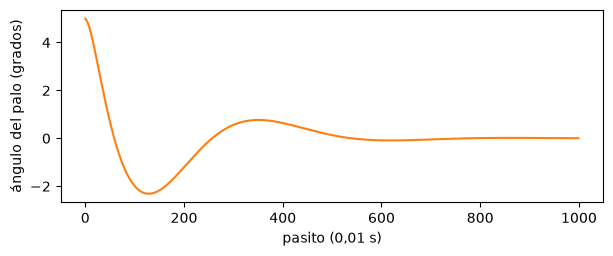

In [19]:
import mujoco
import numpy as np
import matplotlib.pyplot as plt
from math import degrees, radians

# 1. Cargar el robot desde su fichero (sin taller)
modelo = mujoco.MjModel.from_xml_path("robots/palo_escoba.xml")
datos = mujoco.MjData(modelo)

print("Paso de tiempo:", modelo.opt.timestep, "s | motores:", modelo.nu)
print("Rango de la orden del motor:", modelo.actuator_ctrlrange)
print("Topes del carro (articulación 'deslizar'):", modelo.joint("deslizar").range)

# 2. Estado inicial: el palo inclinado 5 grados
datos.qpos[1] = radians(5)
mujoco.mj_forward(modelo, datos)

# 3. El controlador: cuatro ruedecillas (ángulo, giro, carro, velocidad del carro)
GANANCIAS = (3.0, 0.8, 0.1, 0.2)

# 4. El bucle de simulación: 10 segundos
angulos = []
for paso in range(1000):
    x, angulo = datos.qpos
    x_vel, angulo_vel = datos.qvel
    k_ang, k_giro, k_x, k_xvel = GANANCIAS
    orden = k_ang * angulo + k_giro * angulo_vel + k_x * x + k_xvel * x_vel
    datos.ctrl[0] = np.clip(orden, -1, 1)
    mujoco.mj_step(modelo, datos)
    angulos.append(degrees(datos.qpos[1]))
    if paso + 1 in [1, 100, 500, 1000]:
        print("t =", round(datos.time, 2), "s | ángulo =", round(angulos[-1], 2), "grados | carro en",
              round(datos.qpos[0], 2), "m")

# 5. Dibujar el ángulo
plt.figure(figsize=(7, 2.5))
plt.plot(angulos, color="tab:orange")
plt.xlabel("pasito (0,01 s)")
plt.ylabel("ángulo del palo (grados)")
plt.show()

El palo empieza inclinado 5 grados; al cabo de 1 segundo el controlador ya lo ha llevado **al otro lado**
(−2 grados: se ha pasado un poco, como un columpio), a los 5 segundos está a 0,14 grados y a los **10
segundos**, a 0,0, con el carro de vuelta en el centro. Es el mismo palo de tu
NB11, controlado sin viento.


### Paso 2 · Lectura guiada: busca las seis ideas

Vuelve al script con esta tabla al lado. Cada línea "rara" es una de las seis ideas de hoy:

| Línea del script | Idea | Qué hace |
|---|---|---|
| `import numpy as np`, `import matplotlib.pyplot as plt` | **6 · apodos** | Saca dos cajas de herramientas con sus apodos de siempre. `matplotlib.pyplot` es un **submódulo**. |
| `from math import degrees, radians` | **6 · `from ... import`** | Trae dos funciones para usarlas sin `math.` delante: `radians(5)` pasa 5 grados a radianes; `degrees(...)`, al revés. (¡Lo que en el NB11 hacías a mano con tu constante `GRADOS`!) |
| `mujoco.MjModel.from_xml_path("robots/palo_escoba.xml")` | **5 · el punto** | Dentro del módulo `mujoco` está `MjModel` (el tipo "modelo"), y dentro de él la función `from_xml_path`, "créalo desde un fichero". Puntos encadenados: se leen de izquierda a derecha. |
| `modelo.opt.timestep`, `modelo.nu` | **5 · atributos** | Datos, **sin paréntesis**: se leen. |
| `modelo.joint("deslizar")` | **5 · método** | **Con paréntesis**: hace algo (buscar la articulación con ese nombre). Y lo que devuelve tiene su propio atributo, `.range`. |
| `modelo.actuator_ctrlrange` | **3 · lista de listas** | Una tabla: una fila por motor, con su mínimo y su máximo. Este robot tiene un motor, así que es `[[-1. 1.]]`: una fila. |
| `GANANCIAS = (3.0, 0.8, 0.1, 0.2)` | **2 · tupla** | Cuatro números que van juntos y **no deben cambiar** durante la simulación. MAYÚSCULAS: es una constante (NB11). |
| `x, angulo = datos.qpos` | **2 · desempaquetar** | `datos.qpos` tiene dos números; cada uno va a su caja. Lo mismo con `datos.qvel` y con `GANANCIAS` (cuatro cajas de golpe). |
| `np.clip(orden, -1, 1)` | **6 · módulo con apodo** | La función `clip` ("recortar") de NumPy: deja `orden` entre −1 y 1. Es tu `if empuje > EMPUJE_MAXIMO` del NB11, en una línea. |
| `angulos[-1]` | (NB09) | La última foto de la lista: la que se acaba de añadir. |
| `if paso + 1 in [1, 100, 500, 1000]:` | **4 · `in`** | "¿Es este pasito uno de los que quiero ver?" Sin `in`, serían tres `or`. |
| `plt.figure(figsize=(7, 2.5))` | **1 · argumento con nombre** + **2 · tupla** | El tamaño del dibujo, `(ancho, alto)`, pasado por su nombre. |
| `plt.plot(angulos, color="tab:orange")` | **1 · argumento con nombre** | La lista por posición; el color, opcional, por nombre. |

Fíjate en que la **física** del script es la de siempre: `mj_forward` (colocar sin que pase el tiempo,
NB01), un `for` con `mj_step` (NB07), escribir la orden en `datos.ctrl` (NB10) y grabar en una lista (NB09).
Lo nuevo es solo **la forma de escribirlo**.


### Paso 3 · Comprobar tus lecturas

Leer bien es poder **predecir**. Para cada celda de abajo, piensa antes qué saldrá, y después ejecútala.

¿Qué es `modelo.actuator_ctrlrange[0][1]`? (Fila 0, columna 1: el máximo del primer motor.)


In [20]:
print(modelo.actuator_ctrlrange[0][1])

1.0


**1.0**. Y la tupla `GANANCIAS`, ¿se puede cambiar por dentro?

In [21]:
GANANCIAS[0] = 5.0

TypeError: 'tuple' object does not support item assignment

No: `TypeError: 'tuple' object does not support item assignment`, como en el apartado 2. Si quieres otras
ruedecillas, se crea **otra** tupla entera (lo harás en los retos). Así nadie las cambia por accidente a mitad
de simulación.

¿Y si confundes método y atributo (apartado 5)? `modelo.nu` es un dato; ponerle paréntesis es "llamar a un
número":


In [22]:
print(modelo.nu())

TypeError: 'int' object is not callable

`TypeError: 'int' object is not callable`: el mismo error que `math.pi()`. Al revés, `modelo.joint`
**sin** paréntesis no da error, pero tampoco busca nada: es la función sin llamar.

Por último, `in` con los nombres de las articulaciones (apartado 4). El nombre de la articulación número `i`
es `modelo.joint(i).name`:


In [23]:
nombres = []
for i in range(modelo.njnt):
    nombres.append(modelo.joint(i).name)

print(nombres)
print("¿Tiene una articulación 'bisagra'?", "bisagra" in nombres)
print("¿Tiene 'rodilla'?", "rodilla" in nombres)

['deslizar', 'bisagra']
¿Tiene una articulación 'bisagra'? True
¿Tiene 'rodilla'? False


### Paso 4 · La foto, como la hace un profesional

`taller.foto` esconde unas pocas líneas. Aquí las tienes al descubierto: un **dibujante** de MuJoCo
(`mujoco.Renderer`) creado con **argumentos con nombre** (`height` y `width`, alto y ancho en píxeles),
que primero **actualiza la escena** con los datos de ahora, luego **pinta** una imagen y al final se
**cierra** (tres métodos, con paréntesis). La imagen se enseña con `plt.imshow`:


Couldn't open plugin directory: No such file or directory
No plugins found, falling back on no decorations


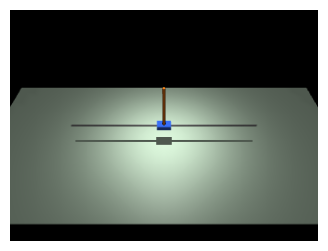

In [24]:
dibujante = mujoco.Renderer(modelo, height=240, width=320)
dibujante.update_scene(datos)
imagen = dibujante.render()
dibujante.close()

plt.figure(figsize=(4, 3))
plt.imshow(imagen)
plt.axis("off")
plt.show()

Es la cámara "por defecto" de MuJoCo, sin los ajustes de distancia y ángulo que hace `taller`: el palo,
derecho, sobre el carro, al final de los 10 segundos. (Si ves alguna línea de aviso técnico encima de la
foto, es la tarjeta gráfica de la Raspberry Pi hablando; `taller` las tapa, aquí no.)


### Tus retos

**Reto 1.** En el script, cambia el ángulo inicial a **20 grados** (`radians(20)`) y vuelve a ejecutarlo. ¿Lo
salva el controlador?

**Reto 2.** Crea unas ganancias **sin** las ruedecillas del carro: `GANANCIAS = (3.0, 0.8, 0.0, 0.0)`. Con
el ángulo inicial en 5 grados otra vez, ¿dónde acaba el carro a los 10 segundos? (Recuerda la práctica del
NB11.)

**Reto 3.** Escribe una línea que imprima solo los nombres de los **motores** cuyo nombre contenga la palabra
`"emp"`, recorriendo `range(modelo.nu)` y usando `modelo.actuator(i).name` con `in`.

**Reto 4 (lectura).** Escribe tú, en un comentario, qué hace cada parte de esta línea:
`mujoco.mj_step(modelo, datos)`.

<details>
<summary>▶ Solución Reto 1</summary>

Sí, por los pelos: a los 10 s el palo está otra vez a 0,0 grados y el carro en el centro. Pero para
ponerse debajo de un palo tan inclinado, el carro tiene que hacer un viaje enorme: llega hasta **1,51 m**
del centro, muy cerca del tope (1,8). Prueba con **30 grados**: el carro llega al tope, se para en seco y el
palo se cae. Lo que limita aquí no es la mente (el controlador) sino el cuerpo y el mundo: la fuerza del
motor y la longitud del raíl.
</details>

<details>
<summary>▶ Solución Reto 2</summary>

Acaba **contra el tope** (x = 1,8 m) y el palo, tumbado. Sin mirar el carro, el controlador endereza el palo
al principio, pero el carro se queda con velocidad hacia un lado y nadie lo frena hasta que choca. Es lo mismo
que descubriste en la práctica del NB11 con `politica_a_mano`: si la política no mira el carro, nadie cuida
del carro.
</details>

<details>
<summary>▶ Solución Reto 3</summary>

```python
for i in range(modelo.nu):
    if "emp" in modelo.actuator(i).name:
        print(modelo.actuator(i).name)
```

Sale `empuje`, el único motor. Con el humanoide (17 motores) este truco sirve, por ejemplo, para encontrar
todos los de la rodilla: `"knee" in nombre`.
</details>

<details>
<summary>▶ Solución Reto 4</summary>

```python
# mujoco      -> el módulo (la caja de herramientas), importado con "import mujoco"
# .mj_step    -> una función de ese módulo (con paréntesis: hace algo): "da un pasito"
# (modelo,    -> primer argumento, por posición: el plano (lo que no cambia)
#  datos)     -> segundo argumento, por posición: el estado de ahora, que mj_step actualiza
```

La has escrito decenas de veces desde el NB02; ahora sabes leer cada pieza.
</details>

### Qué has aprendido de MuJoCo hoy

- Un script de MuJoCo "de verdad" carga el robot **desde su fichero**: `mujoco.MjModel.from_xml_path(ruta)` y
  `mujoco.MjData(modelo)`, que es lo que hace `taller.cargar` por dentro.
- A distinguir en el código de MuJoCo **atributos** (`modelo.nu`, `modelo.opt.timestep`), **métodos**
  (`modelo.joint("deslizar")`) y tablas (`modelo.actuator_ctrlrange`).
- Las formas típicas: tuplas de ganancias, desempaquetar `datos.qpos`, `np.clip`, `in` para elegir pasitos o
  nombres, `figsize=(..., ...)`.
- Cómo se hace una foto sin `taller`: `mujoco.Renderer(modelo, height=..., width=...)`, `update_scene`,
  `render`, `close`.

En la práctica del NB12 verás los **vectores** dentro de MuJoCo: las posiciones 3D de cada pieza
(`xpos`) y la gravedad como una flecha de tres números.


## 11 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Ahora sí: en la **Parte 2** empezamos con las **matemáticas** del aprendizaje. El **NB12** arranca con las **flechas** (los vectores), con dibujos hechos por el ordenador... y ya sabrás leer todas las líneas que los dibujan.
